# Import Library

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import math 
import json
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from skorch import NeuralNetClassifier
from skorch.helper import predefined_split
from skorch.callbacks import EpochScoring
from IPython.display import display
import torch
print(torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SAVE_DIR = "learning_curves"
os.makedirs(SAVE_DIR, exist_ok=True)

from sklearn.model_selection import cross_val_score, StratifiedKFold

NumPy: 2.5.1
Pandas: 3.0.5
2.13.0+cu132
Device: cuda


# Load Dataset

In [4]:
data = pd.read_csv(
    "gsar_a_2521295_sm1572.csv",
    sep=";",
    skiprows=1,
    encoding="utf-8-sig"
)

data = data.dropna(subset=["SMILES", "label"]).reset_index(drop=True)
data["label"] = data["label"].astype(int)

print(data.shape)
data[["compound ID", "SMILES", "label"]].head()

(846, 8)


,compound ID,SMILES,label
0,A001,FC1(F)CN(c2c(C(F)(F)F)cnc3[nH]c(C4=CCNC4)cc23)C1,1
1,A002,CC(C)[C@@H](NC(=O)c1cc(-c2cnn3cc(-c4ccc(OCCN5C...,1
2,A003,O=C(NCC(F)(F)F)c1cc(-c2cnc3[nH]c(C4=CCCNC4)cc3...,1
3,A004,CN1CC=C(c2cc3cc(-c4csc(C(=O)NCC(F)(F)F)c4)cnc3...,1
4,A005,O=C(NCC(F)(F)F)c1cc(-c2cnc3[nH]c(C4=CCNCC4)cc3...,1


# Tokenisasi SMILES


In [5]:
X_smiles = data["SMILES"].values

charset = set("".join(list(X_smiles)) + "!E")
char_to_int = dict((c, i) for i, c in enumerate(charset))
int_to_char = dict((i, c) for i, c in enumerate(charset))

embed = max([len(smile) for smile in X_smiles]) + 5
vocab_size = len(charset)

print("Jumlah karakter unik (vocab_size):", vocab_size)
print("Panjang embedding (embed):", embed)
print(str(charset))

Jumlah karakter unik (vocab_size): 34
Panjang embedding (embed): 102
{'F', 'c', 's', 'r', 'B', '4', ']', 'N', 'C', 'I', '5', 'P', 'S', '2', '6', 'o', 'H', '@', '3', '=', 'O', '[', '\\', '/', '!', '(', 'E', '1', 'l', '#', ')', '-', 'n', '+'}


In [6]:
char_to_int

{'F': 0,
 'c': 1,
 's': 2,
 'r': 3,
 'B': 4,
 '4': 5,
 ']': 6,
 'N': 7,
 'C': 8,
 'I': 9,
 '5': 10,
 'P': 11,
 'S': 12,
 '2': 13,
 '6': 14,
 'o': 15,
 'H': 16,
 '@': 17,
 '3': 18,
 '=': 19,
 'O': 20,
 '[': 21,
 '\\': 22,
 '/': 23,
 '!': 24,
 '(': 25,
 'E': 26,
 '1': 27,
 'l': 28,
 '#': 29,
 ')': 30,
 '-': 31,
 'n': 32,
 '+': 33}

# Fungsi Vectorize

In [7]:
def vectorize(smiles, charset, char_to_int, embed):
    one_hot = np.zeros((smiles.shape[0], embed, len(charset)), dtype=np.int8)
    for i, smile in enumerate(smiles):
        one_hot[i, 0, char_to_int["!"]] = 1
        for j, c in enumerate(smile):
            if c in char_to_int:
                one_hot[i, j + 1, char_to_int[c]] = 1
        one_hot[i, len(smile) + 1:, char_to_int["E"]] = 1
    return one_hot[:, 0:-1, :]

X_onehot = vectorize(X_smiles, charset, char_to_int, embed)
X_encoded = np.argmax(X_onehot, axis=2)

# Visual Hasil Encoding SMILES

In [8]:
print("vocab_size:", vocab_size, "| embed:", embed)
print("X_onehot shape :", X_onehot.shape)
print("X_encoded shape:", X_encoded.shape)

idx = 0

print("\nSMILES asli:", X_smiles[idx])
print()
print("One-hot encoding, 10 posisi pertama:")
print(X_onehot[idx][:10])

print("Integer-encoded, 20 posisi pertama:")
print(X_encoded[idx][:20])

decoded = "".join([int_to_char[i] for i in X_encoded[idx]])
print("Hasil decode balik:", decoded)

vocab_size: 34 | embed: 102
X_onehot shape : (846, 101, 34)
X_encoded shape: (846, 101)

SMILES asli: FC1(F)CN(c2c(C(F)(F)F)cnc3[nH]c(C4=CCNC4)cc23)C1

One-hot encoding, 10 posisi pertama:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]]
Integer-encoded, 20 posisi pertama:
[24  0  8 27 25  0 30  8  7 25  1 13  1 25  8 25  0 30 25  0]
Ha

# Penggabungan Hasil Encoding SMILES dengan Label

In [9]:
y = data["label"].values

print("X_encoded shape:", X_encoded.shape)
print("y shape         :", y.shape)

assert X_encoded.shape[0] == y.shape[0], "Jumlah baris SMILES dan label tidak sinkron!"

X_encoded shape: (846, 101)
y shape         : (846,)


# Training Pool

In [10]:
X = X_encoded
y_arr = y.reshape(-1, 1) if y.ndim == 1 else y

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y_arr,
    test_size=0.3,
    random_state=42,
    stratify=y_arr
)

print("Training pool :", X_train.shape)
print("Holdout test  :", X_test.shape)

Training pool : (592, 101)
Holdout test  : (254, 101)


# Siapkan Data Train & Validation

In [11]:
X_pool = X_train.astype(np.int64)
Y_pool = Y_train.flatten().astype(np.int64) if Y_train.ndim > 1 else Y_train.astype(np.int64)

X_test_int = X_test.astype(np.int64)
Y_test_int = Y_test.flatten().astype(np.int64) if Y_test.ndim > 1 else Y_test.astype(np.int64)

# Split training pool (70%) jadi Train & Validation (misal 80:20)
X_tr, X_val, Y_tr, Y_val = train_test_split(
    X_pool, Y_pool,
    test_size=0.2,
    random_state=42,
    stratify=Y_pool
)

print("Train      :", X_tr.shape)
print("Validation :", X_val.shape)
print("Holdout Test (dikunci):", X_test_int.shape)

Train      : (473, 101)
Validation : (119, 101)
Holdout Test (dikunci): (254, 101)


# Pembentukan model Baseline

In [12]:
class LSTMBaselineSkorch(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, units_list=[64]):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm_layers = nn.ModuleList()
        input_size = embedding_dim
        for units in units_list:
            self.lstm_layers.append(nn.LSTM(input_size=input_size, hidden_size=units, batch_first=True))
            input_size = units
        self.output_layer = nn.Linear(units_list[-1], 2)

    def forward(self, x):
        out = self.embedding(x)
        for lstm in self.lstm_layers:
            out, _ = lstm(out)
        out = out[:, -1, :]
        return self.output_layer(out)


def build_skorch_net_with_history(units_list, X_val, Y_val, vocab_size, embedding_dim=50,
                                   epochs=50, lr=0.001, batch_size=32, device=device):
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.long),
        torch.tensor(Y_val, dtype=torch.long)
    )

    return NeuralNetClassifier(
        module=LSTMBaselineSkorch,
        module__vocab_size=vocab_size,
        module__embedding_dim=embedding_dim,
        module__units_list=units_list,
        max_epochs=epochs,
        lr=lr,
        optimizer=torch.optim.Adam,
        criterion=nn.CrossEntropyLoss,
        batch_size=batch_size,
        device=device,
        train_split=predefined_split(val_dataset),
        callbacks=[
            ("train_acc", EpochScoring(scoring="accuracy", on_train=True, name="train_acc", lower_is_better=False)),
        ],
        verbose=0
    )


def compute_confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN


def plot_confusion_matrix_image(TP, TN, FP, FN, model_name="", dataset_name=""):
    cm = np.array([[TP, FN],
                   [FP, TN]])

    fig, ax = plt.subplots(figsize=(5, 4.5))
    im = ax.imshow(cm, cmap="Blues")

    labels = ["Aktif (1)", "Inaktif (0)"]
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Kelas Prediksi")
    ax.set_ylabel("Kelas Aktual")
    ax.set_title(f"Confusion Matrix - {model_name} ({dataset_name})")

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black",
                     fontsize=14, fontweight="bold")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()




# Learning Curve per Baseline

In [13]:

def plot_learning_curve(history, model_name, save_dir=SAVE_DIR):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["loss"], label="Training Loss")
    axes[0].plot(history["val_loss"], label="Validation Loss")
    axes[0].set_title(f"Loss Curve - {model_name}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["accuracy"], label="Training Accuracy")
    axes[1].plot(history["val_accuracy"], label="Validation Accuracy")
    axes[1].set_title(f"Accuracy Curve - {model_name}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"learning_curve_{model_name.replace(' ', '_')}.png")
    plt.savefig(save_path, dpi=150)
    print(f"Learning curve disimpan di: {save_path}")
    plt.show()


def compute_metrics(TP, TN, FP, FN, eps=1e-10):
    accuracy  = (TP + TN) / (TP + TN + FP + FN + eps)
    recall    = TP / (TP + FN + eps)
    precision = TP / (TP + FP + eps)
    f1_score  = 2 * (precision * recall) / (precision + recall + eps)
    return {"accuracy": accuracy, "recall": recall, "precision": precision, "f1_score": f1_score}

# Konfigurasi Baseline

In [14]:
baseline_configs = {
    "Baseline 1": [64],
    "Baseline 2": [64, 128],
    "Baseline 3": [64, 128, 256],
}

config_table = []

for name, units_list in baseline_configs.items():
    config_table.append({
        "Konfigurasi": name,
        "Jumlah Layer LSTM": len(units_list),
        "Node per Lapisan": str(tuple(units_list)),
        "Lapisan Output": "Dense 1 neuron, aktivasi Sigmoid",
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Optimizer": "Adam",
        "Epoch": 50,
    })

config_df = pd.DataFrame(config_table).set_index("Konfigurasi")
display(config_df)

,Jumlah Layer LSTM,Node per Lapisan,Lapisan Output,Learning Rate,Batch Size,Optimizer,Epoch
Konfigurasi,,,,,,,
Baseline 1,1,"(64,)","Dense 1 neuron, aktivasi Sigmoid",0.001,32,Adam,50
Baseline 2,2,"(64, 128)","Dense 1 neuron, aktivasi Sigmoid",0.001,32,Adam,50
Baseline 3,3,"(64, 128, 256)","Dense 1 neuron, aktivasi Sigmoid",0.001,32,Adam,50


# Training Baseline dengan Validation Split

TRAINING | Baseline 1 | LSTM layers: [64]
Learning curve disimpan di: learning_curves\learning_curve_Baseline_1.png


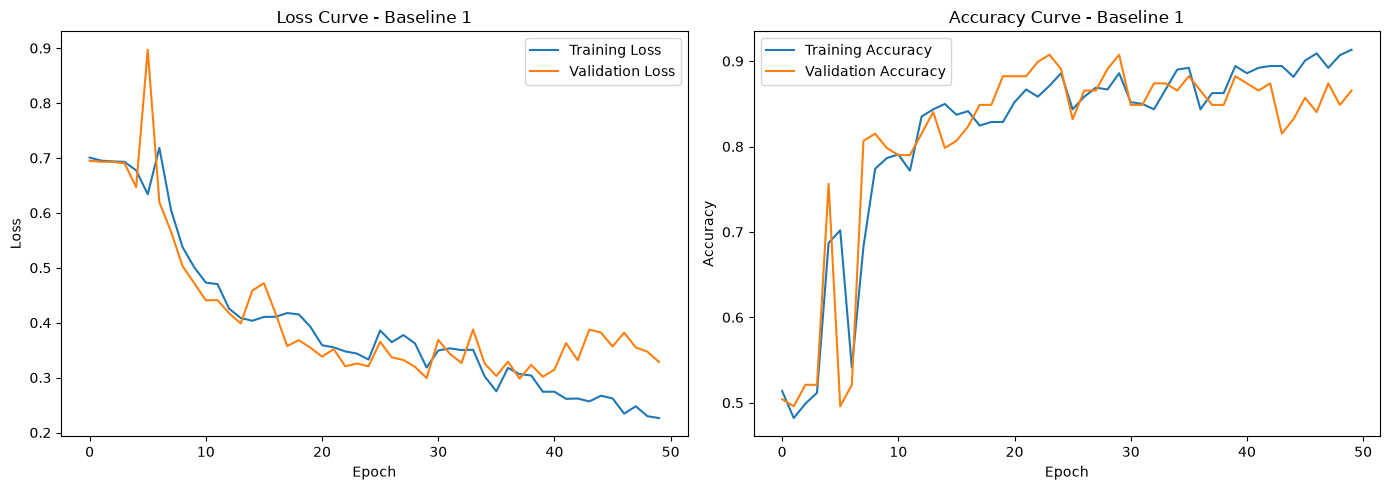

>>> Evaluasi Baseline 1 pada Train <<<


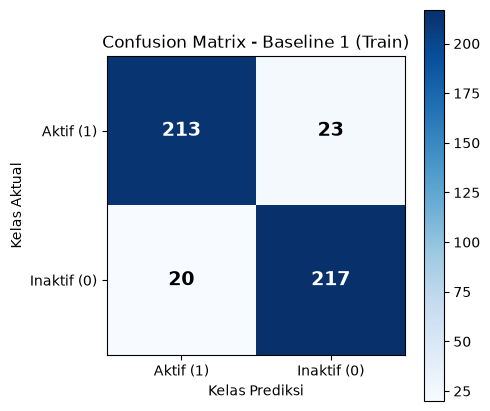

Accuracy  : 0.9091
Recall    : 0.9025
Precision : 0.9142
F1-Score  : 0.9083
>>> Evaluasi Baseline 1 pada Holdout Test <<<


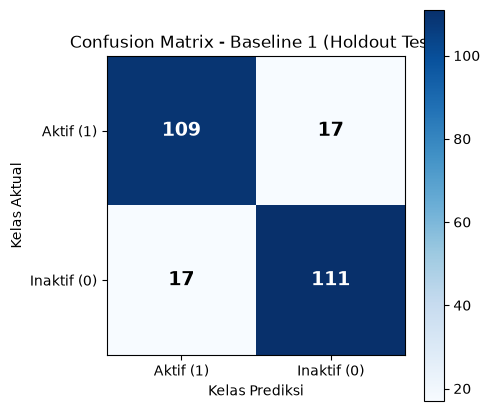

Accuracy  : 0.8661
Recall    : 0.8651
Precision : 0.8651
F1-Score  : 0.8651
TRAINING | Baseline 2 | LSTM layers: [64, 128]
Learning curve disimpan di: learning_curves\learning_curve_Baseline_2.png


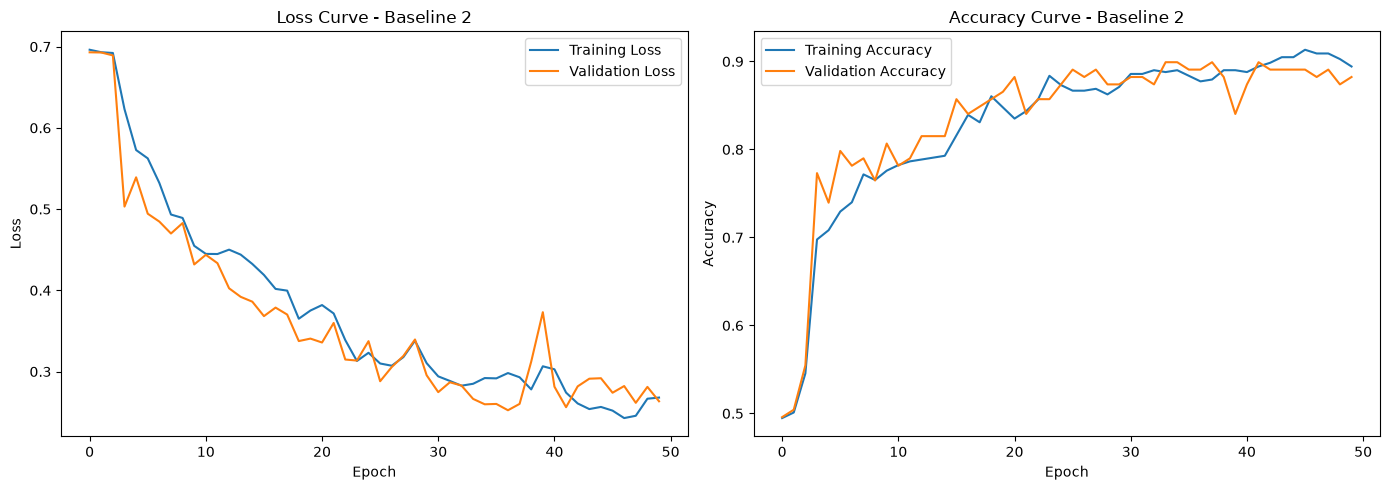

>>> Evaluasi Baseline 2 pada Train <<<


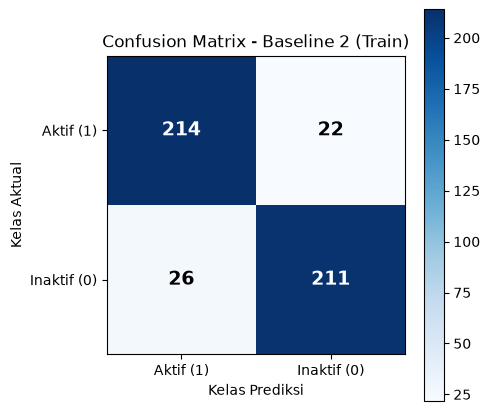

Accuracy  : 0.8985
Recall    : 0.9068
Precision : 0.8917
F1-Score  : 0.8992
>>> Evaluasi Baseline 2 pada Holdout Test <<<


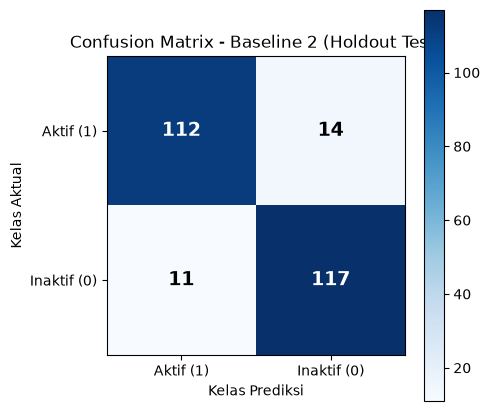

Accuracy  : 0.9016
Recall    : 0.8889
Precision : 0.9106
F1-Score  : 0.8996
TRAINING | Baseline 3 | LSTM layers: [64, 128, 256]
Learning curve disimpan di: learning_curves\learning_curve_Baseline_3.png


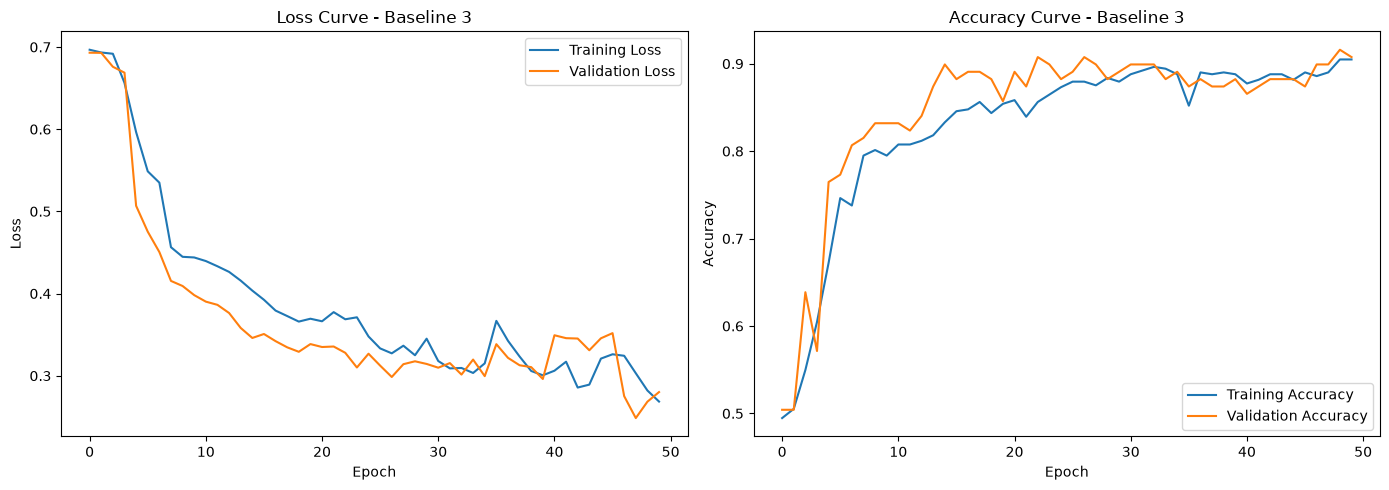

>>> Evaluasi Baseline 3 pada Train <<<


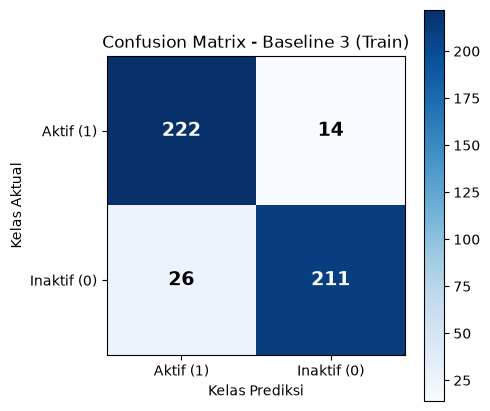

Accuracy  : 0.9154
Recall    : 0.9407
Precision : 0.8952
F1-Score  : 0.9174
>>> Evaluasi Baseline 3 pada Holdout Test <<<


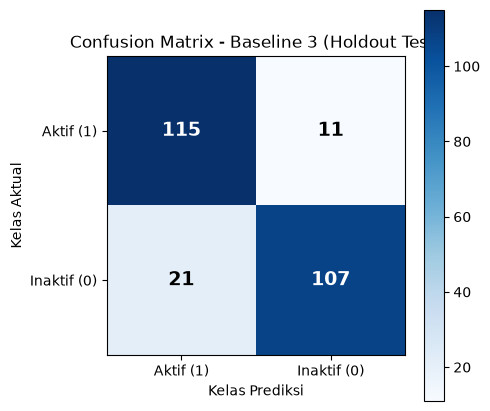

Accuracy  : 0.8740
Recall    : 0.9127
Precision : 0.8456
F1-Score  : 0.8779


In [15]:
final_baseline_nets = {}
baseline_histories = {}
baseline_eval_results = {}

for name, units_list in baseline_configs.items():
    print("="*60)
    print(f"TRAINING | {name} | LSTM layers: {units_list}")
    print("="*60)

    net = build_skorch_net_with_history(
        units_list, X_val, Y_val,
        vocab_size=vocab_size, epochs=50, lr=0.001, batch_size=32
    )
    net.fit(X_tr, Y_tr)
    final_baseline_nets[name] = net

    history = {
        "loss": [row["train_loss"] for row in net.history],
        "val_loss": [row["valid_loss"] for row in net.history],
        "accuracy": [row["train_acc"] for row in net.history],
        "val_accuracy": [row["valid_acc"] for row in net.history],
    }
    baseline_histories[name] = history
    plot_learning_curve(history, model_name=name)

    # Evaluasi ke Train
    y_pred_train = net.predict(X_tr)
    TP_tr, TN_tr, FP_tr, FN_tr = compute_confusion_matrix(Y_tr, y_pred_train)
    metrics_train = compute_metrics(TP_tr, TN_tr, FP_tr, FN_tr)

    print(f">>> Evaluasi {name} pada Train <<<")
    plot_confusion_matrix_image(TP_tr, TN_tr, FP_tr, FN_tr, model_name=name, dataset_name="Train")
    print(f"Accuracy  : {metrics_train['accuracy']:.4f}")
    print(f"Recall    : {metrics_train['recall']:.4f}")
    print(f"Precision : {metrics_train['precision']:.4f}")
    print(f"F1-Score  : {metrics_train['f1_score']:.4f}")

    # Evaluasi ke Test
    y_pred_test = net.predict(X_test_int)
    TP_te, TN_te, FP_te, FN_te = compute_confusion_matrix(Y_test_int, y_pred_test)
    metrics_test = compute_metrics(TP_te, TN_te, FP_te, FN_te)

    print(f">>> Evaluasi {name} pada Holdout Test <<<")
    plot_confusion_matrix_image(TP_te, TN_te, FP_te, FN_te, model_name=name, dataset_name="Holdout Test")
    print(f"Accuracy  : {metrics_test['accuracy']:.4f}")
    print(f"Recall    : {metrics_test['recall']:.4f}")
    print(f"Precision : {metrics_test['precision']:.4f}")
    print(f"F1-Score  : {metrics_test['f1_score']:.4f}")

    baseline_eval_results[name] = {"train": metrics_train, "test": metrics_test}

# Ringkasan Hasil Training Baseline ke Satu DataFrame

In [16]:
summary_rows = []

for name, units_list in baseline_configs.items():
    metrics_train = baseline_eval_results[name]["train"]
    metrics_test = baseline_eval_results[name]["test"]

    summary_rows.append({
        "Konfigurasi": name,
        "Jumlah Layer LSTM": len(units_list),
        "Node per Lapisan": str(tuple(units_list)),
        "Train Accuracy": metrics_train["accuracy"],
        "Train F1": metrics_train["f1_score"],
        "Test Accuracy": metrics_test["accuracy"],
        "Test F1": metrics_test["f1_score"],
    })

full_summary_df = pd.DataFrame(summary_rows).set_index("Konfigurasi")
display(full_summary_df)

,Jumlah Layer LSTM,Node per Lapisan,Train Accuracy,Train F1,Test Accuracy,Test F1
Konfigurasi,,,,,,
Baseline 1,1,"(64,)",0.909091,0.908316,0.866142,0.865079
Baseline 2,2,"(64, 128)",0.898520,0.899160,0.901575,0.899598
Baseline 3,3,"(64, 128, 256)",0.915433,0.917355,0.874016,0.877863


# Parameter Monarch Butterfly Optimization (MBO)

In [17]:
mbo_params_table = pd.DataFrame([
    {"Parameter": "Jumlah Populasi (NP)", "Nilai": 50},
    {"Parameter": "Rasio Migrasi (p)", "Nilai": "[0.1, 0.25, 0.5]"},
    {"Parameter": "Langkah Maksimum (Smax)", "Nilai": 1.0},
    {"Parameter": "Faktor Skala (alpha)", "Nilai": "alpha_t = Smax / t^2 (Persamaan 11)"},
    {"Parameter": "Iterasi Maksimum", "Nilai": 50},
]).set_index("Parameter")

display(mbo_params_table)

,Nilai
Parameter,
Jumlah Populasi (NP),50
Rasio Migrasi (p),"[0.1, 0.25, 0.5]"
Langkah Maksimum (Smax),1.0
Faktor Skala (alpha),alpha_t = Smax / t^2 (Persamaan 11)
Iterasi Maksimum,50


# Skema optimasi MBO

In [18]:
mbo_schemes = {
    "MBO 1": {"p": 0.1},
    "MBO 2": {"p": 0.25},
    "MBO 3": {"p": 0.5},
}

mbo_schemes_table = pd.DataFrame([
    {"Skema": name, "Rasio Migrasi (p)": cfg["p"]}
    for name, cfg in mbo_schemes.items()
]).set_index("Skema")

display(mbo_schemes_table)

,Rasio Migrasi (p)
Skema,
MBO 1,0.10
MBO 2,0.25
MBO 3,0.50


# Definisi ruang pencarian Hyperparameter LSTM

In [19]:
# Catatan asumsi: MBO mengoptimasi jumlah node tiap lapisan LSTM (3 lapisan). Learning
# rate TIDAK dioptimasi, pakai nilai tetap (FIXED_LR).

DIM = 3  # jumlah variabel keputusan: units_layer1, units_layer2, units_layer3

BOUNDS = np.array([
    [16, 128],     # units layer 1
    [32, 256],     # units layer 2
    [64, 512],     # units layer 3
])

FIXED_LR = 0.001

def decode_solution(vector):
    """Ubah vektor kontinu MBO menjadi hyperparameter LSTM yang valid."""
    units1 = int(np.clip(round(vector[0]), BOUNDS[0, 0], BOUNDS[0, 1]))
    units2 = int(np.clip(round(vector[1]), BOUNDS[1, 0], BOUNDS[1, 1]))
    units3 = int(np.clip(round(vector[2]), BOUNDS[2, 0], BOUNDS[2, 1]))
    return {"units_list": [units1, units2, units3], "lr": FIXED_LR}

# Fitness Function

In [20]:
def fitness_function(vector, X_tr, Y_tr, X_val, Y_val, vocab_size, epochs=20, batch_size=32):
    """
    Fitness = validation loss pada epoch terakhir. MBO MEMINIMALKAN nilai ini
    (bukan memaksimalkan accuracy). valid_loss dihitung otomatis oleh skorch
    tiap epoch lewat train_split=predefined_split(val_dataset), jadi tidak
    perlu predict() manual ke X_val.
    epochs sengaja lebih kecil (20) dibanding training final (50) untuk
    mempercepat proses pencarian MBO, karena tiap evaluasi fitness akan
    dipanggil ratusan-ribuan kali (NP x max_iter x jumlah skema).
    """
    config = decode_solution(vector)

    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.long),
        torch.tensor(Y_val, dtype=torch.long)
    )

    net = NeuralNetClassifier(
        module=LSTMBaselineSkorch,
        module__vocab_size=vocab_size,
        module__embedding_dim=50,
        module__units_list=config["units_list"],
        max_epochs=epochs,
        lr=config["lr"],
        optimizer=torch.optim.Adam,
        criterion=nn.CrossEntropyLoss,
        batch_size=batch_size,
        device=device,
        train_split=predefined_split(val_dataset),
        verbose=0
    )

    try:
        net.fit(X_tr, Y_tr)
        return net.history[-1, "valid_loss"]
    except Exception as e:
        print(f"Evaluasi gagal untuk konfigurasi {config}: {e}")
        return float("inf")  # fitness terburuk (loss besar) kalau kombinasi hyperparameter gagal dilatih

# Implementasi Algoritma MBO

In [21]:
def initialize_population(NP, dim, bounds):
    population = np.zeros((NP, dim))
    for d in range(dim):
        population[:, d] = np.random.uniform(bounds[d, 0], bounds[d, 1], NP)
    return population


def migration_operator(subpop1, subpop2, p, dim):
    """Migration operator: individu subpop1 diperbarui berdasarkan subpop1 atau subpop2."""
    NP1 = len(subpop1)
    new_subpop1 = np.copy(subpop1)

    for i in range(NP1):
        for d in range(dim):
            r = np.random.uniform(0, 1) * 1.0  # dikali periode migrasi (asumsi = 1.0)
            if r <= p:
                r1 = np.random.randint(0, NP1)
                new_subpop1[i, d] = subpop1[r1, d]
            else:
                r2 = np.random.randint(0, len(subpop2))
                new_subpop1[i, d] = subpop2[r2, d]

    return new_subpop1


def butterfly_adjusting_operator(subpop2, best_solution, alpha_t, p, BAR, dim):
    """Butterfly adjusting operator: individu subpop2 diperbarui mendekati solusi terbaik."""
    NP2 = len(subpop2)
    new_subpop2 = np.copy(subpop2)

    for i in range(NP2):
        for d in range(dim):
            if np.random.uniform(0, 1) <= p:
                new_subpop2[i, d] = best_solution[d]
            else:
                r3 = np.random.randint(0, NP2)
                new_subpop2[i, d] = subpop2[r3, d]

                if np.random.uniform(0, 1) > BAR:
                    dx = levy_step(dim)
                    new_subpop2[i, d] += alpha_t * (dx[d] - 0.5)

    return new_subpop2


def levy_step(dim, beta=1.5):
    """Random walk berdasarkan Levy flight, dipakai di butterfly adjusting operator."""
    sigma = (math.gamma(1 + beta) * np.sin(np.pi * beta / 2) /
             (math.gamma((1 + beta) / 2) * beta * (2 ** ((beta - 1) / 2)))) ** (1 / beta)
    u = np.random.normal(0, sigma, dim)
    v = np.random.normal(0, 1, dim)
    step = u / (np.abs(v) ** (1 / beta))
    return step


def clip_to_bounds(population, bounds):
    for d in range(bounds.shape[0]):
        population[:, d] = np.clip(population[:, d], bounds[d, 0], bounds[d, 1])
    return population

# Fungsi utama MBO

In [22]:
def run_mbo(p, X_tr, Y_tr, X_val, Y_val, vocab_size, NP=10, max_iter=10, Smax=1.0, BAR=5/12,
            dim=DIM, bounds=BOUNDS, fitness_epochs=20, scheme_name=""):

    NP1 = int(np.ceil(p * NP))
    NP2 = NP - NP1

    population = initialize_population(NP, dim, bounds)

    print(f"[{scheme_name}] Mengevaluasi populasi awal ({NP} individu)...")
    fitness = np.zeros(NP)
    for i, ind in enumerate(population):
        fitness[i] = fitness_function(ind, X_tr, Y_tr, X_val, Y_val, vocab_size, epochs=fitness_epochs)
        print(f"[{scheme_name}] Individu {i+1}/{NP} dievaluasi - fitness (loss): {fitness[i]:.4f}")

    best_idx = np.argmin(fitness)
    best_solution = population[best_idx].copy()
    best_fitness = fitness[best_idx]

    convergence_curve = [best_fitness]

    for t in range(1, max_iter + 1):
        alpha_t = Smax / (t ** 2)

        sorted_idx = np.argsort(fitness)  # ascending: loss terkecil duluan
        population = population[sorted_idx]
        fitness = fitness[sorted_idx]

        subpop1 = population[:NP1]
        subpop2 = population[NP1:]

        new_subpop1 = migration_operator(subpop1, subpop2, p, dim)
        new_subpop2 = butterfly_adjusting_operator(subpop2, best_solution, alpha_t, p, BAR, dim)

        new_population = np.vstack([new_subpop1, new_subpop2])
        new_population = clip_to_bounds(new_population, bounds)

        print(f"[{scheme_name}] Iterasi {t}/{max_iter} - mengevaluasi {NP} individu baru...")
        new_fitness = np.zeros(NP)
        for i, ind in enumerate(new_population):
            new_fitness[i] = fitness_function(ind, X_tr, Y_tr, X_val, Y_val, vocab_size, epochs=fitness_epochs)
            print(f"[{scheme_name}] Iterasi {t} - Individu {i+1}/{NP} dievaluasi - fitness (loss): {new_fitness[i]:.4f}")

        combined_population = np.vstack([population, new_population])
        combined_fitness = np.concatenate([fitness, new_fitness])

        best_indices = np.argsort(combined_fitness)[:NP]  # ambil NP individu dengan loss terkecil
        population = combined_population[best_indices]
        fitness = combined_fitness[best_indices]

        if fitness[0] < best_fitness:
            best_fitness = fitness[0]
            best_solution = population[0].copy()

        convergence_curve.append(best_fitness)
        print(f"[{scheme_name}] Iterasi {t}/{max_iter} SELESAI - Best Fitness (Loss): {best_fitness:.4f}")

    return best_solution, best_fitness, convergence_curve

# Jalankan MBO untuk ketiga skema

In [23]:
mbo_results = {}

for scheme_name, cfg in mbo_schemes.items():
    print("="*60)
    print(f"MENJALANKAN {scheme_name} | Rasio Migrasi (p) = {cfg['p']}")
    print("="*60)

    best_solution, best_fitness, convergence_curve = run_mbo(
        p=cfg["p"],
        X_tr=X_tr, Y_tr=Y_tr,
        X_val=X_val, Y_val=Y_val,
        vocab_size=vocab_size,
        NP=10,
        max_iter=10,
        Smax=1.0,
        fitness_epochs=20,
        scheme_name=scheme_name
    )

    mbo_results[scheme_name] = {
        "best_solution": best_solution,
        "best_fitness": best_fitness,
        "convergence_curve": convergence_curve,
        "best_config": decode_solution(best_solution),
    }

    print(f"\n{scheme_name} SELESAI | Best Loss (Validation): {best_fitness:.4f}")
    print(f"Konfigurasi terbaik: {mbo_results[scheme_name]['best_config']}")

MENJALANKAN MBO 1 | Rasio Migrasi (p) = 0.1
[MBO 1] Mengevaluasi populasi awal (10 individu)...
[MBO 1] Individu 1/10 dievaluasi - fitness (loss): 0.3744
[MBO 1] Individu 2/10 dievaluasi - fitness (loss): 0.3839
[MBO 1] Individu 3/10 dievaluasi - fitness (loss): 0.3598
[MBO 1] Individu 4/10 dievaluasi - fitness (loss): 0.3148
[MBO 1] Individu 5/10 dievaluasi - fitness (loss): 0.3551
[MBO 1] Individu 6/10 dievaluasi - fitness (loss): 0.3432
[MBO 1] Individu 7/10 dievaluasi - fitness (loss): 0.3727
[MBO 1] Individu 8/10 dievaluasi - fitness (loss): 0.3912
[MBO 1] Individu 9/10 dievaluasi - fitness (loss): 0.3419
[MBO 1] Individu 10/10 dievaluasi - fitness (loss): 0.3601
[MBO 1] Iterasi 1/10 - mengevaluasi 10 individu baru...
[MBO 1] Iterasi 1 - Individu 1/10 dievaluasi - fitness (loss): 0.3191
[MBO 1] Iterasi 1 - Individu 2/10 dievaluasi - fitness (loss): 0.3134
[MBO 1] Iterasi 1 - Individu 3/10 dievaluasi - fitness (loss): 0.3125
[MBO 1] Iterasi 1 - Individu 4/10 dievaluasi - fitness (l

# Plot Kurva Konvergensi ketiga skema MBO

Kurva konvergensi disimpan di: learning_curves\mbo_convergence_curve.png


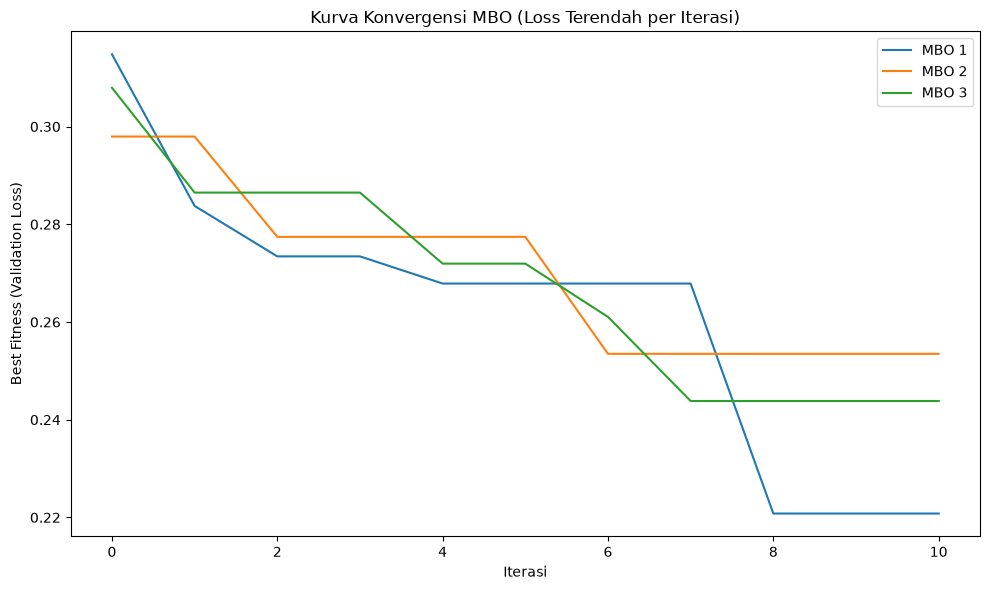

In [24]:
plt.figure(figsize=(10, 6))

for scheme_name, result in mbo_results.items():
    plt.plot(result["convergence_curve"], label=scheme_name)

plt.title("Kurva Konvergensi MBO (Loss Terendah per Iterasi)")
plt.xlabel("Iterasi")
plt.ylabel("Best Fitness (Validation Loss)")
plt.legend()
plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "mbo_convergence_curve.png")
plt.savefig(save_path, dpi=150)
print(f"Kurva konvergensi disimpan di: {save_path}")
plt.show()

# Ringkasan Hasil MBO

In [25]:
mbo_summary_rows = []

for scheme_name, result in mbo_results.items():
    config = result["best_config"]
    mbo_summary_rows.append({
        "Skema": scheme_name,
        "Rasio Migrasi (p)": mbo_schemes[scheme_name]["p"],
        "Units Layer 1": config["units_list"][0],
        "Units Layer 2": config["units_list"][1],
        "Units Layer 3": config["units_list"][2],
        "Learning Rate": config["lr"],
        "Best Loss (Validation)": result["best_fitness"],
    })

mbo_summary_df = pd.DataFrame(mbo_summary_rows).set_index("Skema")
display(mbo_summary_df)

,Rasio Migrasi (p),Units Layer 1,Units Layer 2,Units Layer 3,Learning Rate,Best Loss (Validation)
Skema,,,,,,
MBO 1,0.10,42,247,173,0.001,0.220795
MBO 2,0.25,58,85,491,0.001,0.253487
MBO 3,0.50,27,96,431,0.001,0.243827


# Evaluasi MBO

FINAL MODEL | MBO 1 | Konfigurasi: {'units_list': [42, 247, 173], 'lr': 0.001}
Checkpoint lama ditemukan tapi konfigurasi berbeda, training ulang: MBO 1
Model disimpan: learning_curves\mbo_final_models\MBO_1_params.pt
Learning curve disimpan di: learning_curves\learning_curve_MBO_(MBO_1).png


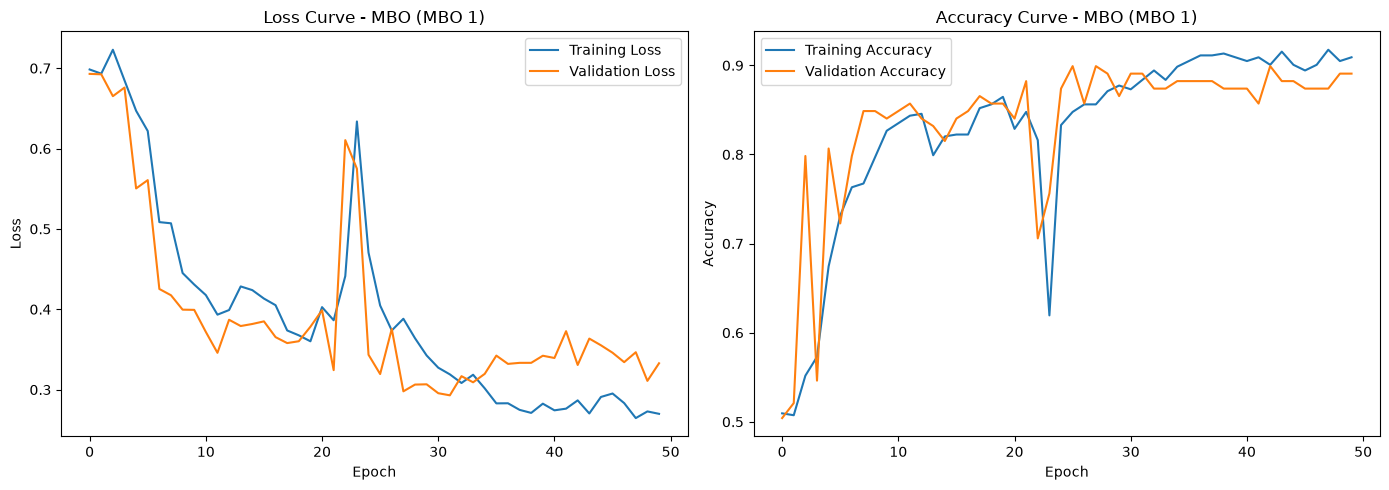

>>> Evaluasi MBO (MBO 1) pada Train <<<


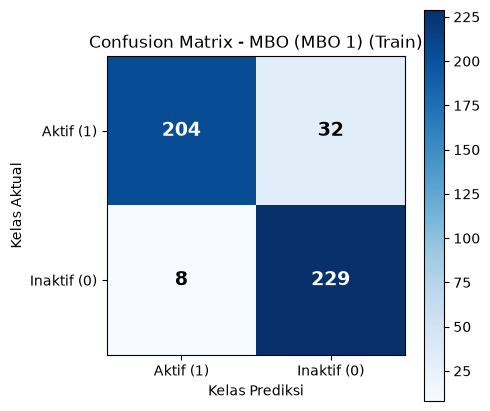

Accuracy  : 0.9154
Recall    : 0.8644
Precision : 0.9623
F1-Score  : 0.9107
>>> Evaluasi MBO (MBO 1) pada Holdout Test <<<


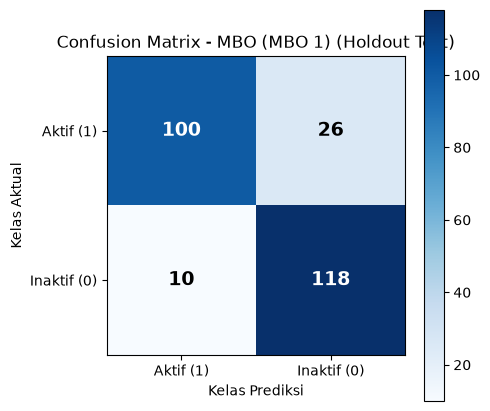

Accuracy  : 0.8583
Recall    : 0.7937
Precision : 0.9091
F1-Score  : 0.8475
FINAL MODEL | MBO 2 | Konfigurasi: {'units_list': [58, 85, 491], 'lr': 0.001}
Checkpoint lama ditemukan tapi konfigurasi berbeda, training ulang: MBO 2
Model disimpan: learning_curves\mbo_final_models\MBO_2_params.pt
Learning curve disimpan di: learning_curves\learning_curve_MBO_(MBO_2).png


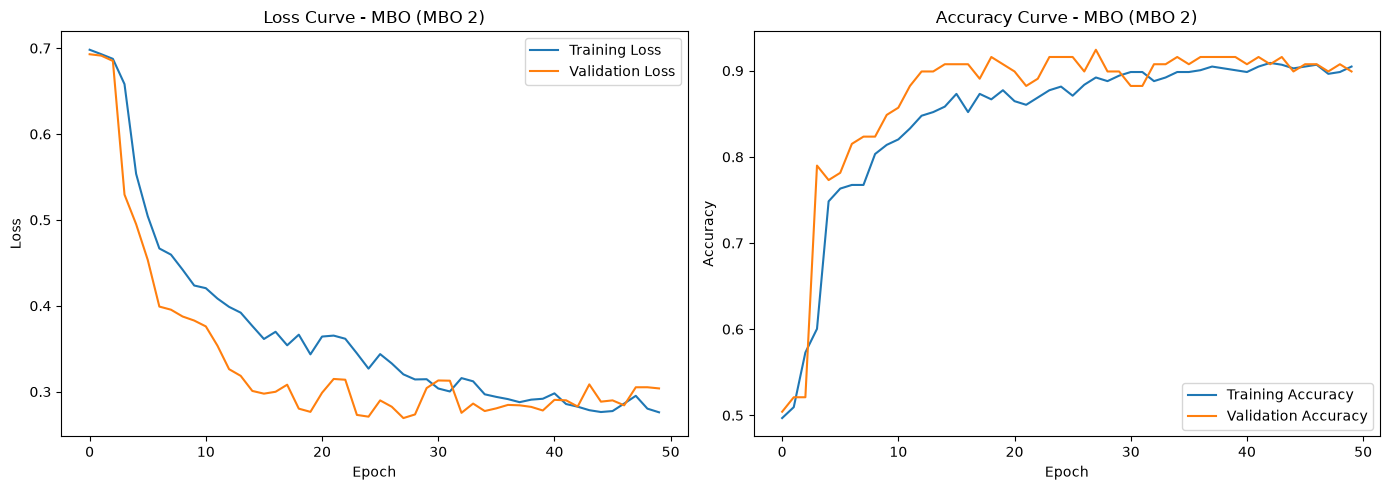

>>> Evaluasi MBO (MBO 2) pada Train <<<


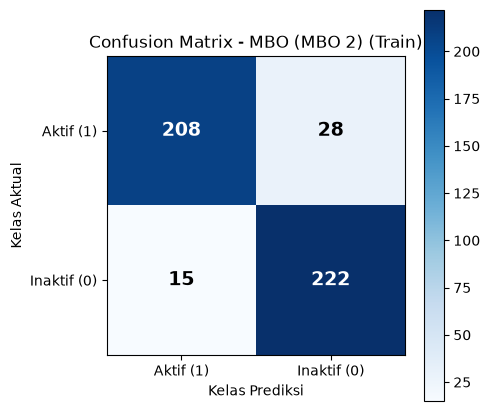

Accuracy  : 0.9091
Recall    : 0.8814
Precision : 0.9327
F1-Score  : 0.9063
>>> Evaluasi MBO (MBO 2) pada Holdout Test <<<


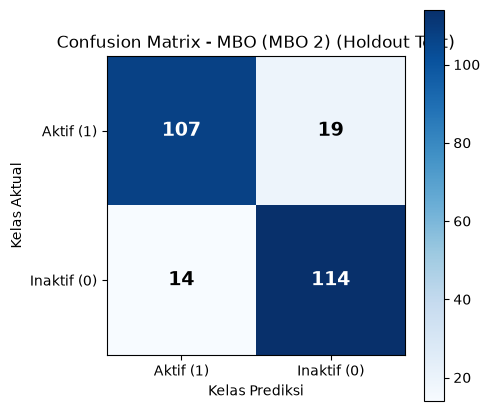

Accuracy  : 0.8701
Recall    : 0.8492
Precision : 0.8843
F1-Score  : 0.8664
FINAL MODEL | MBO 3 | Konfigurasi: {'units_list': [27, 96, 431], 'lr': 0.001}
Checkpoint lama ditemukan tapi konfigurasi berbeda, training ulang: MBO 3
Model disimpan: learning_curves\mbo_final_models\MBO_3_params.pt
Learning curve disimpan di: learning_curves\learning_curve_MBO_(MBO_3).png


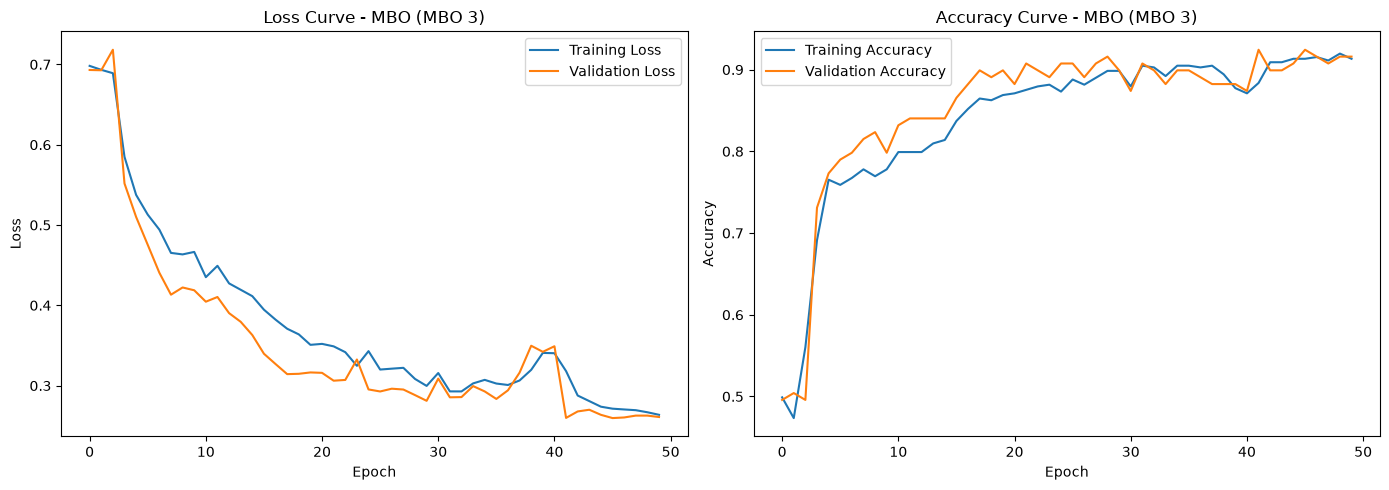

>>> Evaluasi MBO (MBO 3) pada Train <<<


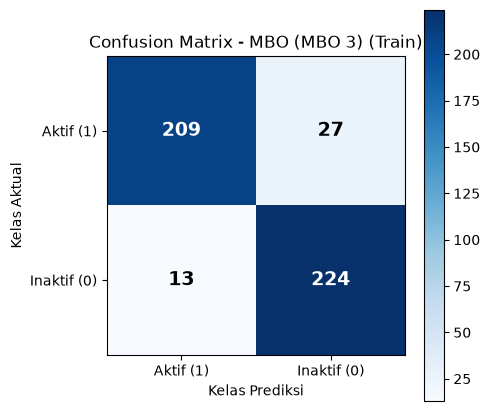

Accuracy  : 0.9154
Recall    : 0.8856
Precision : 0.9414
F1-Score  : 0.9127
>>> Evaluasi MBO (MBO 3) pada Holdout Test <<<


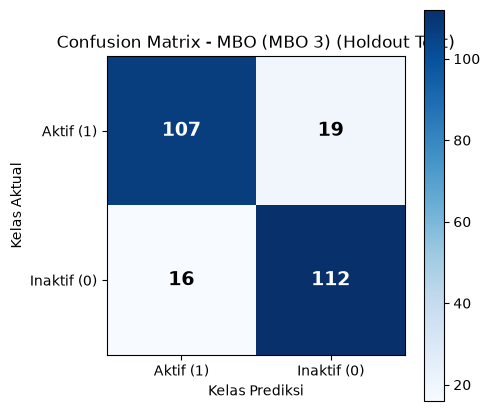

Accuracy  : 0.8622
Recall    : 0.8492
Precision : 0.8699
F1-Score  : 0.8594


In [26]:
final_mbo_nets = {}
mbo_histories = {}
mbo_eval_results = {}

MODEL_SAVE_DIR = os.path.join(SAVE_DIR, "mbo_final_models")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

for scheme_name, result in mbo_results.items():
    config = result["best_config"]
    print("="*60)
    print(f"FINAL MODEL | {scheme_name} | Konfigurasi: {config}")
    print("="*60)

    safe_name = scheme_name.replace(" ", "_")
    params_path = os.path.join(MODEL_SAVE_DIR, f"{safe_name}_params.pt")
    history_path = os.path.join(MODEL_SAVE_DIR, f"{safe_name}_history.json")
    config_path = os.path.join(MODEL_SAVE_DIR, f"{safe_name}_config.json")

    net = build_skorch_net_with_history(
        config["units_list"], X_val, Y_val,
        vocab_size=vocab_size,
        epochs=50,           # epoch penuh untuk model final, sesuai Tabel 4 (Iterasi Maksimum)
        lr=config["lr"],
        batch_size=32
    )

    # Cek apakah checkpoint tersimpan cocok dengan konfigurasi hasil MBO run ini.
    # MBO bersifat stokastik: best_config bisa beda tiap run untuk skema yang sama,
    # jadi checkpoint lama bisa punya arsitektur (units_list) yang berbeda -> load_params
    # akan gagal size mismatch kalau dipaksa load tanpa dicek dulu.
    config_matches = False
    if os.path.exists(params_path) and os.path.exists(config_path):
        with open(config_path, "r") as f:
            saved_config = json.load(f)
        config_matches = (saved_config == config)

    if config_matches:
        print(f"Load model tersimpan (konfigurasi cocok): {params_path}")
        net.initialize()
        net.load_params(f_params=params_path, f_history=history_path)
    else:
        if os.path.exists(params_path):
            print(f"Checkpoint lama ditemukan tapi konfigurasi berbeda, training ulang: {scheme_name}")
        else:
            print("Training model final dari nol...")
        net.fit(X_tr, Y_tr)
        net.save_params(f_params=params_path, f_history=history_path)
        with open(config_path, "w") as f:
            json.dump(config, f)
        print(f"Model disimpan: {params_path}")

    final_mbo_nets[scheme_name] = net

    history = {
        "loss": [row["train_loss"] for row in net.history],
        "val_loss": [row["valid_loss"] for row in net.history],
        "accuracy": [row["train_acc"] for row in net.history],
        "val_accuracy": [row["valid_acc"] for row in net.history],
    }
    mbo_histories[scheme_name] = history
    plot_learning_curve(history, model_name=f"MBO ({scheme_name})")

    # Evaluasi ke Train
    y_pred_train = net.predict(X_tr)
    TP_tr, TN_tr, FP_tr, FN_tr = compute_confusion_matrix(Y_tr, y_pred_train)
    metrics_train = compute_metrics(TP_tr, TN_tr, FP_tr, FN_tr)

    print(f">>> Evaluasi MBO ({scheme_name}) pada Train <<<")
    plot_confusion_matrix_image(TP_tr, TN_tr, FP_tr, FN_tr, model_name=f"MBO ({scheme_name})", dataset_name="Train")
    print(f"Accuracy  : {metrics_train['accuracy']:.4f}")
    print(f"Recall    : {metrics_train['recall']:.4f}")
    print(f"Precision : {metrics_train['precision']:.4f}")
    print(f"F1-Score  : {metrics_train['f1_score']:.4f}")

    # Evaluasi ke Test
    y_pred_test = net.predict(X_test_int)
    TP_te, TN_te, FP_te, FN_te = compute_confusion_matrix(Y_test_int, y_pred_test)
    metrics_test = compute_metrics(TP_te, TN_te, FP_te, FN_te)

    print(f">>> Evaluasi MBO ({scheme_name}) pada Holdout Test <<<")
    plot_confusion_matrix_image(TP_te, TN_te, FP_te, FN_te, model_name=f"MBO ({scheme_name})", dataset_name="Holdout Test")
    print(f"Accuracy  : {metrics_test['accuracy']:.4f}")
    print(f"Recall    : {metrics_test['recall']:.4f}")
    print(f"Precision : {metrics_test['precision']:.4f}")
    print(f"F1-Score  : {metrics_test['f1_score']:.4f}")

    mbo_eval_results[scheme_name] = {"train": metrics_train, "test": metrics_test}

# Skema MBO Terbaik 

In [27]:
best_scheme_name = mbo_summary_df["Best Loss (Validation)"].idxmin()
best_metrics_test = mbo_eval_results[best_scheme_name]["test"]

print(f"Skema MBO terbaik: {best_scheme_name}")
print(f"Konfigurasi: {mbo_results[best_scheme_name]['best_config']}")
print(f"Validation Loss: {mbo_summary_df.loc[best_scheme_name, 'Best Loss (Validation)']:.4f}")
print(f"\n>>> Hasil Holdout Test  <<<")
print(f"Accuracy  : {best_metrics_test['accuracy']:.4f}")
print(f"Recall    : {best_metrics_test['recall']:.4f}")
print(f"Precision : {best_metrics_test['precision']:.4f}")
print(f"F1-Score  : {best_metrics_test['f1_score']:.4f}")

Skema MBO terbaik: MBO 1
Konfigurasi: {'units_list': [42, 247, 173], 'lr': 0.001}
Validation Loss: 0.2208

>>> Hasil Holdout Test  <<<
Accuracy  : 0.8583
Recall    : 0.7937
Precision : 0.9091
F1-Score  : 0.8475


# Perbandingan Hyperparameter Tuning: Baseline (Manual) vs MBO (Metaheuristik)

,Tipe,Val Loss (akhir),Test Accuracy,Test F1
Model,,,,
Baseline Terbaik (Baseline 2),Manual (Tanpa Tuning),0.263400,0.901575,0.899598
MBO 1,MBO (Tuned),0.220795,0.858268,0.847458
MBO 2,MBO (Tuned),0.253487,0.870079,0.866397
MBO 3,MBO (Tuned),0.243827,0.862205,0.859438


Perbandingan disimpan di: learning_curves\baseline_vs_mbo_comparison.png


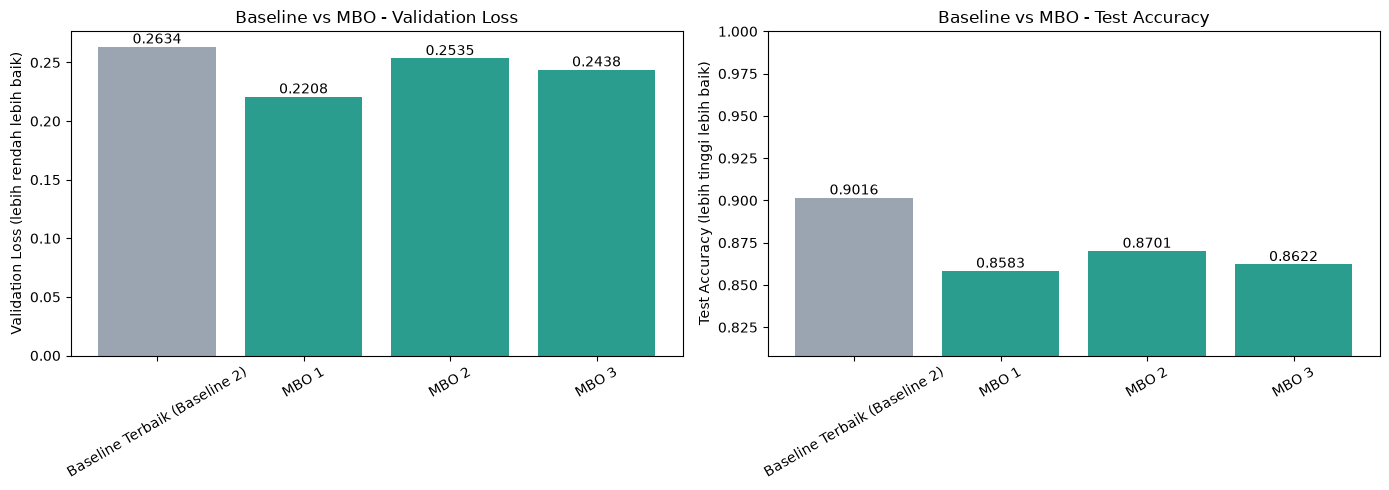

In [28]:
# Baseline pembanding = konfigurasi manual terbaik (val_loss akhir terendah),
# analog ke "default parameters" pada GridSearchCV: dipilih tanpa pencarian
# otomatis, dievaluasi di validation split yang SAMA dengan MBO.
best_baseline_name = min(
    baseline_configs,
    key=lambda name: baseline_histories[name]["val_loss"][-1]
)

comparison_rows = [{
    "Model": f"Baseline Terbaik ({best_baseline_name})",
    "Tipe": "Manual (Tanpa Tuning)",
    "Val Loss (akhir)": baseline_histories[best_baseline_name]["val_loss"][-1],
    "Test Accuracy": baseline_eval_results[best_baseline_name]["test"]["accuracy"],
    "Test F1": baseline_eval_results[best_baseline_name]["test"]["f1_score"],
}]

for scheme_name, result in mbo_results.items():
    comparison_rows.append({
        "Model": scheme_name,
        "Tipe": "MBO (Tuned)",
        "Val Loss (akhir)": result["best_fitness"],
        "Test Accuracy": mbo_eval_results[scheme_name]["test"]["accuracy"],
        "Test F1": mbo_eval_results[scheme_name]["test"]["f1_score"],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#9aa5b1"] + ["#2a9d8f"] * len(mbo_results)

axes[0].bar(comparison_df.index, comparison_df["Val Loss (akhir)"], color=colors)
axes[0].set_ylabel("Validation Loss (lebih rendah lebih baik)")
axes[0].set_title("Baseline vs MBO - Validation Loss")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(comparison_df["Val Loss (akhir)"]):
    axes[0].text(i, v, f"{v:.4f}", ha="center", va="bottom")

axes[1].bar(comparison_df.index, comparison_df["Test Accuracy"], color=colors)
axes[1].set_ylabel("Test Accuracy (lebih tinggi lebih baik)")
axes[1].set_ylim(min(comparison_df["Test Accuracy"]) - 0.05, 1.0)
axes[1].set_title("Baseline vs MBO - Test Accuracy")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(comparison_df["Test Accuracy"]):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, "baseline_vs_mbo_comparison.png")
plt.savefig(save_path, dpi=150)
print(f"Perbandingan disimpan di: {save_path}")
plt.show()